In [2]:
import pandas as pd

In [ ]:
def cargar_y_limpiar(path):
    """Carga un CSV y elimina valores nulos o duplicados en el texto."""
    df = pd.read_csv(path)
    inicial = len(df)

    # Eliminar nulos en las columnas clave
    df = df.dropna(subset=['text', 'summary'])
    # Eliminar textos duplicados
    df = df.drop_duplicates(subset=['text'])

    print(f"[{path}] Registros iniciales: {inicial} | Tras limpieza: {len(df)} | Eliminados: {inicial - len(df)}")
    return df

print("Cargando datasets...")
df_train = cargar_y_limpiar('MLSUM_dataset/es_train.csv')
df_val   = cargar_y_limpiar('MLSUM_dataset/es_validation.csv')
df_test  = cargar_y_limpiar('MLSUM_dataset/es_test.csv')

Cargando datasets...
[MLSUM_dataset/es_train.csv] Registros iniciales: 266367 | Tras limpieza: 262852 | Eliminados: 3515
[MLSUM_dataset/es_validation.csv] Registros iniciales: 10358 | Tras limpieza: 10146 | Eliminados: 212
[MLSUM_dataset/es_test.csv] Registros iniciales: 13920 | Tras limpieza: 13679 | Eliminados: 241


# Proceso Extractivo con TextRank y Lead-3

Vamos a generar los resúmenes utilizando enfoques puramente extractivos. La extracción consiste en seleccionar las oraciones más relevantes del texto original sin generar vocabulario nuevo.

## 1. Preparación del Entorno y Datos
Para optimizar los tiempos de computación, extraeremos una muestra representativa de 500 noticias de nuestro conjunto de test. Además, cargaremos el modelo de lenguaje de `spaCy`, el cual utilizaremos exclusivamente para tokenizar los textos en oraciones gramaticalmente correctas.

In [3]:
import spacy
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import spacy.cli
spacy.cli.download("es_core_news_md")

✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Extraemos 500 noticias aleatorias del test set que ya está en memoria
df_experimento = df_test.sample(n=500, random_state=42).reset_index(drop=True)
print(f"Subset creado con {len(df_experimento)} noticias.")

# Carga del modelo de spaCy 'es_core_news_md' cargado para la segmentación de oraciones
nlp = spacy.load("es_core_news_md")

Subset creado con 500 noticias.


## 2. Definición del Algoritmo TextRank

TextRank es un algoritmo basado en grafos, inspirado en el PageRank de Google. Su funcionamiento es el siguiente:
1. Divide el texto en oraciones.
2. Convierte cada oración en un vector matemático utilizando **TF-IDF**.
3. Calcula la similitud del coseno entre todas las oraciones para crear un grafo.
4. Aplica el algoritmo de centralidad para puntuar las oraciones más conectadas/relevantes.
5. Extrae las *N* mejores oraciones y las reordena cronológicamente para mantener la cohesión del texto.

In [ ]:
def resumir_textrank(texto, num_frases=3):
    # Separar en frases usando spaCy (descartando las que consideramos muy cortas)
    doc = nlp(str(texto))
    frases = [sent.text.strip() for sent in doc.sents if len(sent.text.split()) > 4]

    if len(frases) <= num_frases:
        return " ".join(frases)

    # Convertir frases a vectores usando TF-IDF
    vectorizer = TfidfVectorizer(stop_words=list(nlp.Defaults.stop_words))
    vectores_frases = vectorizer.fit_transform(frases)

    # Calcular matriz de similitud y aplicar el algoritmo de grafos
    matriz_similitud = cosine_similarity(vectores_frases)
    grafo = nx.from_numpy_array(matriz_similitud)
    puntuaciones = nx.pagerank(grafo)

    # Ordenar las frases por su puntuación de importancia
    frases_ordenadas = sorted(((puntuaciones[i], s) for i, s in enumerate(frases)), reverse=True)
    mejores_frases = frases_ordenadas[:num_frases]

    # Reordenar las frases ganadoras cronológicamente
    indices_mejores = [frases.index(f[1]) for f in mejores_frases]
    indices_mejores.sort()

    return " ".join([frases[i] for i in indices_mejores])

## 3. Ejecución de Modelos y Guardado

A continuación, aplicamos nuestros dos procesos sobre las 500 noticias de prueba:
* **Lead-3:** Un método heurístico clásico en periodismo que simplemente extrae las tres primeras oraciones (basado en la estructura de pirámide invertida).
* **TextRank:** Nuestro algoritmo de grafos.

Finalmente, guardaremos los resultados en un CSV para su posterior evaluación automatizada (con métricas como ROUGE) en el cuaderno final del proyecto.

In [ ]:
# En primer lugar realizamos la prueba con Lead-3 para usarla como referencia a la hora de medir nuestro modelo
print("Generando resúmenes con Lead-3 ...")
def lead_3(texto):
    frases = [sent.text.strip() for sent in nlp(str(texto)).sents]
    return " ".join(frases[:3])

df_experimento['resumen_lead3'] = df_experimento['text'].apply(lead_3)

print("Generando resúmenes con TextRank ...")
df_experimento['resumen_textrank'] = df_experimento['text'].apply(lambda x: resumir_textrank(x, num_frases=3))

df_experimento.to_csv("resultados_extractivos.csv", index=False)
print("Resultados guardados en 'resultados_extractivos.csv'")

Generando resúmenes con Lead-3 ...
Generando resúmenes con TextRank ...
Resultados guardados en 'resultados_extractivos.csv'


# Evaluación de Modelos Extractivos

En este cuaderno vamos a evaluar cuantitativamente el rendimiento de nuestros dos enfoques extractivos: **Lead-3** y **TextRank**.

Para ello, utilizaremos **ROUGE** (Recall-Oriented Understudy for Gisting Evaluation), que es la métrica estándar en la industria para tareas de resumen de texto. ROUGE evalúa la calidad de un resumen automático comparándolo con resúmenes escritos por humanos (nuestra columna de referencia).

Nos centraremos en las puntuaciones F1 de:
* **ROUGE-1:** Coincidencia de unigramas (palabras individuales).
* **ROUGE-2:** Coincidencia de bigramas (pares de palabras). Evalúa la fluidez.
* **ROUGE-L:** Secuencia común más larga (Longest Common Subsequence). Evalúa la estructura general de la oración.

In [9]:
!pip install evaluate rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=1da565f097812c96720792207fcdf1b412b461ba45b2462d1203108d5ab2c442
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


## 1. Carga de Datos y Configuración de Métricas

Comenzamos cargando el dataset que contiene las noticias originales, los resúmenes humanos de referencia y las predicciones generadas por Lead-3 y TextRank en el apartado anterior. Además, inicializamos el objeto evaluador de Hugging Face.

In [10]:
import evaluate

# Cargamos el motor de ROUGE
rouge = evaluate.load("rouge")

print("Evaluando Lead-3...")
results_lead3 = rouge.compute(
    predictions=df_experimento['resumen_lead3'],
    references=df_experimento['summary']
)

print("Evaluando TextRank...")
results_textrank = rouge.compute(
    predictions=df_experimento['resumen_textrank'],
    references=df_experimento['summary']
)

df_metricas = pd.DataFrame([results_lead3, results_textrank], index=['Lead-3', 'TextRank'])

print("\nResultados numéricos (F1-Score):")
display(df_metricas)

Evaluando Lead-3...
Evaluando TextRank...

Resultados numéricos (F1-Score):


,rouge1,rouge2,rougeL,rougeLsum
Lead-3,0.207704,0.065432,0.149138,0.149191
TextRank,0.190883,0.061759,0.138528,0.138626


### Análisis de Resultados Extractivos

Tras evaluar ambos baselines con las métricas ROUGE, observamos un fenómeno clásico en la sumarización de noticias: **el baseline heurístico (Lead-3) supera sistemáticamente al algoritmo basado en grafos (TextRank)**.

Analizando las métricas (F1-Score):
* **ROUGE-1 (Unigramas):** Lead-3 alcanza un ~20.7%, frente al ~19.1% de TextRank. Esto indica que extraer las primeras frases captura un mayor volumen de vocabulario clave idéntico al usado por los periodistas humanos en sus resúmenes.
* **ROUGE-2 y ROUGE-L:** Lead-3 también domina en la captura de bigramas (6.5% vs 6.1%) y en la estructura secuencial (14.9% vs 13.8%).

**¿Por qué ocurre esto?**
Este resultado valida la hipótesis de la **"Pirámide Invertida"** en el sesgo periodístico. En el dataset MLSUM, las noticias están redactadas de forma que la información más vital (el qué, quién, cuándo y dónde) se concentra obligatoriamente en el primer párrafo (*Lead*).

TextRank, al buscar la centralidad matemática a través de todo el documento, tiende a rescatar oraciones del ecuador o final de la noticia que, aunque matemáticamente conectadas con el resto del texto, aportan detalles secundarios que los humanos no incluyen en un resumen conciso.

Por tanto, nuestro reto para el modelo generativo (mT5) será demostrar si una Inteligencia Artificial es capaz de superar la altísima densidad informativa que ya nos regalan de por sí las tres primeras frases de una noticia.

## 5. Visualización y Conclusiones del Enfoque Extractivo

Para comprender mejor qué modelo ha funcionado mejor en nuestra muestra de 500 noticias, visualizaremos los resultados en un gráfico de barras. Finalmente, guardaremos el dataframe completo con los resúmenes para tener un registro de este experimento.

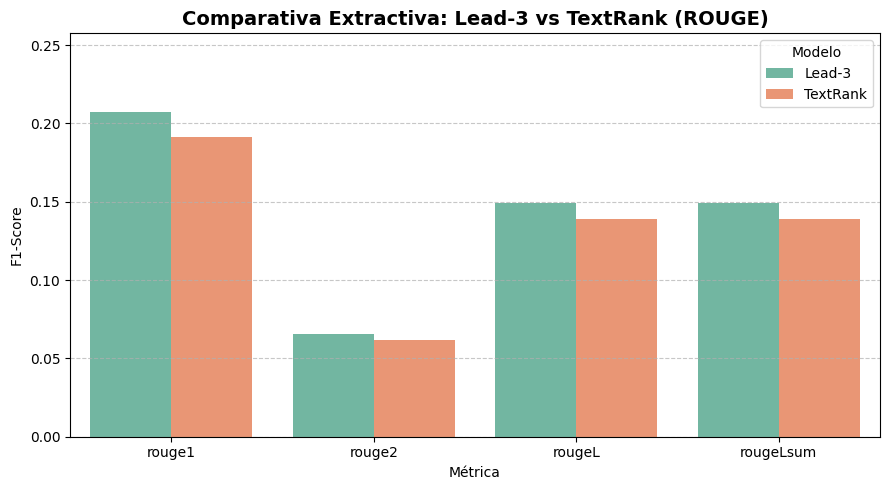

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_metricas.reset_index().rename(columns={'index': 'Modelo'})
df_plot = df_plot.melt(id_vars='Modelo', var_name='Métrica', value_name='Puntuación (F1)')

plt.figure(figsize=(9, 5))
sns.barplot(data=df_plot, x='Métrica', y='Puntuación (F1)', hue='Modelo', palette='Set2')

plt.title('Comparativa Extractiva: Lead-3 vs TextRank (ROUGE)', fontsize=14, fontweight='bold')
plt.ylim(0, max(df_plot['Puntuación (F1)']) + 0.05)
plt.ylabel('F1-Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()


plt.savefig("metricas_extractivas.png", dpi=300)
plt.show()

df_experimento.to_csv("resultados_extractivos_validados.csv", index=False)

# Modelos Generativos: Resumen Automático con mT5

A continuación abordaremos la generación de resúmenes mediante un **enfoque Generativo**. A diferencia de los métodos extractivos, los modelos generativos emplean arquitecturas de Deep Learning basadas en Transformers para "entender" el texto original y redactar un resumen nuevo, fluido y con vocabulario propio.

Utilizaremos el modelo **`josmunpen/mt5-small-spanish-summarization`**, una variante del modelo multilingüe mT5 de Google, reentrenado específicamente por el Instituto de Ingeniería del Conocimiento para la tarea de resumir noticias periodísticas en español.

In [ ]:
!pip install transformers sentencepiece torch tqdm

## 1. Preparación del Entorno y Carga de Datos

Comenzaremos cargando el conjunto de 500 noticias de experimentación. Al cargar el archivo validado del cuaderno anterior, conservaremos las columnas de los resúmenes de Lead-3 y TextRank, lo que nos permitirá hacer la comparativa final en este mismo cuaderno.

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm import tqdm

In [5]:
df_experimento = pd.read_csv("resultados_extractivos_validados.csv")
print(f"Dataset cargado con {len(df_experimento)} noticias preparadas para experimentación.")
df_experimento.head()

Dataset cargado con 500 noticias preparadas para experimentación.


,text,summary,topic,url,title,date,resumen_lead3,resumen_textrank
0,El pleno del Parlamento de Cataluña ha burlado...,El tribunal suspende minutos después del pleno...,ccaa catalunya,http://elpais.com/ccaa/2019/11/12/catalunya/15...,El Parlament burla al Constitucional y aprueba...,12/11/2019,El pleno del Parlamento de Cataluña ha burlado...,El pleno del Parlamento de Cataluña ha burlado...
1,"Hasán Rohaní, presidente iraní, este martes. E...",Teherán asegura que las sanciones de EE UU al ...,internacional actualidad,http://elpais.com/internacional/2019/06/25/act...,El presidente de Irán acusa a EEUU de mentir s...,25/06/2019,"Hasán Rohaní, presidente iraní, este martes. E...",EFE / VÍDEO: REUTERS-QUALITY Irán ha respondid...
2,Era horrible. En la primera década de mi vida ...,"Los problemas de una niña superdotada, el abor...",ccaa catalunya,http://elpais.com/ccaa/2019/08/05/catalunya/15...,Nunca más huérfanos de serie,06/08/2019,Era horrible. En la primera década de mi vida ...,Mi madre y mi abuelo —vivía con nosotros— esta...
3,"Pablo Iglesias, en la presentación del program...",El líder de Podemos no descarta el indulto de ...,politica actualidad,http://elpais.com/politica/2019/10/14/actualid...,Iglesias: “Que Sánchez hable de cumplir las pe...,14/10/2019,"Pablo Iglesias, en la presentación del program...",El secretario general de Podemos siempre ha co...
4,El último episodio se registró este mismo sába...,El 88% de las 135 personas que han muerto en e...,politica actualidad,http://elpais.com/politica/2019/07/05/actualid...,Demasiados ahogados sin socorro,07/07/2019,El último episodio se registró este mismo sába...,"El 1 de junio, por ejemplo, fallecían otras ci..."


## 2. Configuración del Modelo Generativo (mT5)

Cargar modelos de lenguaje grandes requiere gestionar bien la memoria. Utilizaremos la biblioteca `transformers` de Hugging Face. Además, detectaremos automáticamente si el entorno de ejecución cuenta con una GPU (tarjeta gráfica) para acelerar drásticamente el proceso de inferencia.

### ¿Qué modelo estamos utilizando y por qué?

Para esta fase generativa hemos seleccionado el modelo **`josmunpen/mt5-small-spanish-summarization`**. La elección de esta arquitectura se fundamenta en tres razones clave para nuestro proyecto:

1. **Arquitectura mT5 (Multilingual Text-to-Text Transfer Transformer):** Desarrollada originalmente por Google, la familia T5 trata cualquier problema de Procesamiento de Lenguaje Natural como un problema de "texto a texto". Es una red neuronal generativa (Abstractiva) que no se limita a copiar frases, sino que comprende el contexto y redacta con su propio vocabulario.
2. **Especialización (Fine-Tuning):** Este modelo específico ha sido reentrenado (ajustado) exclusivamente para la tarea de resumir textos en **español**, lo que garantiza que la gramática y el vocabulario generado sean naturales y fluidos en nuestro idioma.
3. **Eficiencia Computacional (Versión Small):** Al utilizar la variante *small* (con un número reducido de parámetros frente a versiones *base* o *large*), logramos un equilibrio perfecto. Obtenemos resúmenes de alta calidad sin exceder los límites de memoria RAM y VRAM (GPU) de los entornos de ejecución estándar, permitiendo una experimentación ágil.


In [6]:
model_name = "josmunpen/mt5-small-spanish-summarization"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Descargando el modelo...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

Descargando el modelo...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


## 3. Generación de Resúmenes (Inferencia)

Definimos la función que orquestará la redacción del resumen. Aquí aplicamos varios parámetros críticos del estado del arte:
* `max_length`: Limitamos la entrada a 512 tokens (el contexto óptimo de mT5) y la salida a un máximo de 150 tokens.
* `num_beams`: Usamos *Beam Search* (búsqueda en haz) con 4 ramas. El modelo explora 4 formas distintas de redactar la frase simultáneamente y se queda con la gramaticalmente más coherente.
* `length_penalty`: Forzamos al modelo a no crear resúmenes excesivamente largos ni cortos.
* `no_repeat_ngram_size`: Evita el "tartamudeo", prohíbe repetir el mismo bigrama dos veces. Esto hace el texto más limpio.

In [7]:
tqdm.pandas(desc="Redactando resúmenes")

def resumir_generativo(texto, max_len=150):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, max_length=512).to(device)

    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            max_length=max_len,
            min_length=30,
            length_penalty=1.0,
            num_beams=8,
            no_repeat_ngram_size=2,
            early_stopping=True
        )

    resumen = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return resumen

df_experimento['resumen_generativo'] = df_experimento['text'].progress_apply(resumir_generativo)

print("Resúmenes generados.")

Redactando resúmenes: 100%|██████████| 500/500 [06:50<00:00,  1.22it/s]

Resúmenes generados.


## 4. Evaluación Final: Extractivo vs Generativo

Con la generación completada, utilizamos la métrica **ROUGE** para enfrentar a nuestro nuevo modelo contra los baselines anteriores (Lead-3 y TextRank) basándonos en el solapamiento con los resúmenes humanos reales.

In [11]:
import evaluate

rouge = evaluate.load("rouge")

print("Evaluando Lead-3...")
res_lead3 = rouge.compute(predictions=df_experimento['resumen_lead3'], references=df_experimento['summary'])

print("Evaluando TextRank...")
res_textrank = rouge.compute(predictions=df_experimento['resumen_textrank'], references=df_experimento['summary'])

print("Evaluando Modelo Generativo (mT5)...")
res_mt5 = rouge.compute(predictions=df_experimento['resumen_generativo'], references=df_experimento['summary'])

df_metricas_finales = pd.DataFrame([res_lead3, res_textrank, res_mt5], index=['Lead-3', 'TextRank', 'mT5 Generativo'])

print("\n>>> Resultados Numéricos (F1-Score):")
display(df_metricas_finales)

Evaluando Lead-3...
Evaluando TextRank...
Evaluando Modelo Generativo (mT5)...

>>> Resultados Numéricos (F1-Score):


,rouge1,rouge2,rougeL,rougeLsum
Lead-3,0.207704,0.065432,0.149138,0.149191
TextRank,0.190883,0.061759,0.138528,0.138626
mT5 Generativo,0.237094,0.056618,0.175552,0.175948


## 5. Visualización Comparativa y Guardado

Representamos los resultados finales para ilustrar la conclusión de nuestro proyecto: ¿Es capaz la IA generativa de superar la densidad informativa del "primer párrafo" periodístico (Lead-3) ofreciendo al mismo tiempo un texto redactado de forma natural?

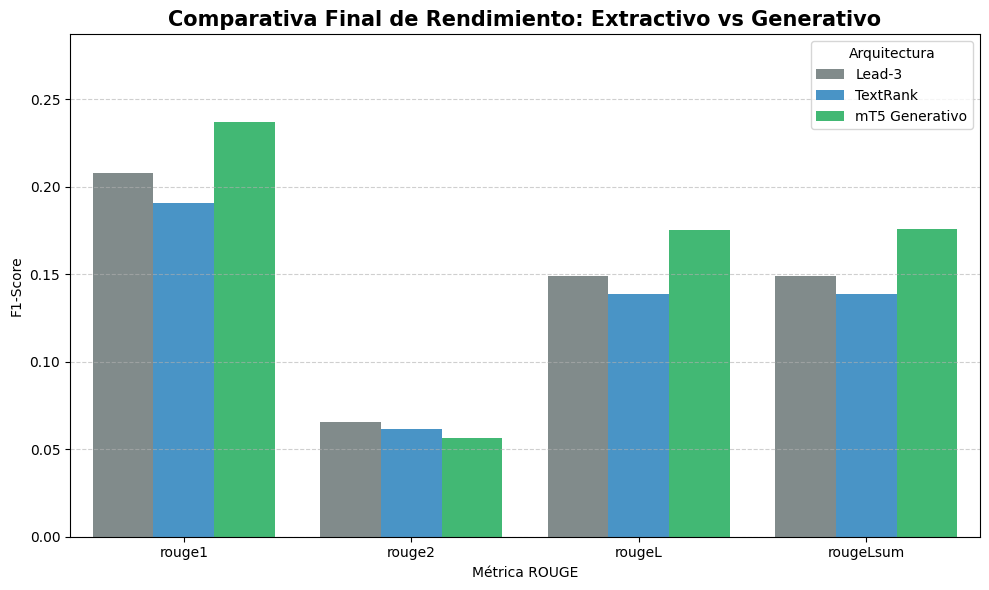

Datos guardados en 'resultados_finales.csv'.


In [13]:
df_plot_final = df_metricas_finales.reset_index().rename(columns={'index': 'Modelo'})
df_plot_final = df_plot_final.melt(id_vars='Modelo', var_name='Métrica ROUGE', value_name='F1-Score')

plt.figure(figsize=(10, 6))
colores = ['#7f8c8d', '#3498db', '#2ecc71']
sns.barplot(data=df_plot_final, x='Métrica ROUGE', y='F1-Score', hue='Modelo', palette=colores)

plt.title('Comparativa Final de Rendimiento: Extractivo vs Generativo', fontsize=15, fontweight='bold')
plt.ylim(0, max(df_plot_final['F1-Score']) + 0.05)
plt.ylabel('F1-Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Arquitectura')
plt.tight_layout()

plt.savefig("grafica_final_proyecto.png", dpi=300)
plt.show()

df_experimento.to_csv("resultados_finales.csv", index=False)
print("Datos guardados en 'resultados_finales.csv'.")

### 6. Conclusiones

El análisis de las métricas ROUGE revela conclusiones fundamentales sobre la sumarización automática de noticias en español:

1. **Superioridad Generativa (ROUGE-1 y ROUGE-L):** El modelo generativo (mT5) logra superar al baseline extractivo más duro (Lead-3). Con un ROUGE-1 cercano al 24% y un ROUGE-L del 17.5%, demostramos que la arquitectura Transformer es capaz de condensar información de todo el documento, superando el sesgo periodístico de la pirámide invertida.
2. **El efecto del parafraseo (ROUGE-2):** Observamos que mT5 puntúa ligeramente por debajo de Lead-3 en ROUGE-2 (5.7% vs 6.5%). Esto es un comportamiento esperado en modelos generativos: al abstraer y redactar con vocabulario propio (usando sinónimos o alterando la sintaxis), la coincidencia estricta de bigramas exactos disminuye, a pesar de que la fluidez y legibilidad del texto suelen ser superiores para un lector humano.
3. **Limitaciones de TextRank:** El enfoque basado puramente en grafos queda en último lugar. Las noticias contienen demasiada información periférica en sus párrafos finales, lo que "engaña" a la centralidad del grafo y extrae oraciones que no pertenecen al núcleo informativo de la noticia.*texto en cursiva*